In [1]:
%matplotlib inline
import torch
import torchvision
from torch.utils import data
from torchvision import transforms
from d2l import torch as d2l 

d2l.use_svg_display()


%matplotlib inline 是jupyter 专用的魔法指令 前面带着%这个标志的
作用很简单 就是告诉Jupyter 以后画图直接显示在notebook里面不要弹窗口
比如之前用的plt.show()画的图在某些环境下可能会试图弹出一个窗口， 而不是嵌入在你的代码的格子下面
import torch 
导入 torch.来使用里面的功能
the torch package contains data structures for multi-dimensional tensors and defines mathematical operations over these tensors 
torch 这个包提供了多维张量的数据结构并定义了对这些张量能做的各种数学运算
这句话tensor 
additional it provides many utilities for efficient seerializaion of Tensors and arbitrary types and other usseful utilities 
 另外 它还提供了很多的工具能把tensor 保存/读取， 以及别的一些使用的小工具
 serialization  序列化， 大致理解就是把数据存在硬盘上， 或者从硬盘上读回来
 it has a cuda counterpart that enable s you to run your tensor computations on an NVIDA gpu with compute capanility > 3.0 
 它还有一个对应的CUDA版本 能让你的tensor运算跑在GPU显卡上要求显卡计算能力大于3.0 
总结： torch 这个库核心提供了两样东西， tensor 这种数据结构， 以及能在这些tensor上做的数学运算， 顺便还能利用显卡加速


计算能力， >= 3.0是一个什么概念
computer capability 是NVIDIA 给每一代芯片构定了一个版本号，用来标记这个块显卡， 支持哪些新的计算特性， 这里可以类比plc的固件版本号， 版本越新支持的功能就越多
这份几千行的Source代码,是PyTorch这个库真正启动时,内部要做的"体检和装配"工作——检查有没有GPU、加载底层C++扩展、注册几百个数学函数的名字等等

torch.tensor(...) 核心 创建一个张量
tensor.shape 张量的属性， 查看形状
tensor.numpy() . squeeze() .reshape() 张量自带的方法， 格式转换
torch.nn 搭建神经网络层Linear sequential 
torch.optim 优化器 SGD 
torch.utils.data (Dataset. DataLoader) 数据加载 
torch.cuda 检查使用GPU以后用到的显卡训练时碰到

torch vision 这个库是官方专门为图像视觉任务配套的一个补充的库
torch 是数学计算工具箱， torchvision 是专门为图片打造的额外的工具
torchvition.datasets.FashionMNIST -我们反复研究的那个数据集类
torchvision.tansforms.ToTensor 把图片转成0-1 浮点数 的那个转换器
后面会用到的transforms.Resize()调整图片大小
torch 负责通用的张量运算， torchvision 负责专门处理图片的相关数据集， 转换工具 
torchvision 这个工具箱 分了好几个小抽屉，  datasets ,常见的数据集，
transform 图片转换工具，   
models 别人训练好现成的模型， 比如ResNet 
io 读写图片，
ops 一些视觉专用的运算 比如目标检测
utils 一些杂项  
——autograd_registrations _meta_registrations 内部注册机制 永远不需要看 

这跟我们之前了解的torch 的方式一样
_image_backend ='PIL' 
_video_backend ='pyav'
def set_image_backend(backend)
def get_image_backend() 

这几个函数是让你可以切换用那个底层的库来解码图片默认是pil你记得_image_fromarray那个pil转换吗，这里就是配置这个， 这一块你几乎永远都不需要碰到， 
一句话总结：torch vision __init__ 本质上打开总闸门， 把datasets tansforms 这几个抽屉的门都打开， 顺便留几个很少用的配置开关， 真正干活的代码都藏在datasets , transforms 这些自己的文件里， 比如我们之前度过的mnist.py , datasets 这个子模块
 查文档的经验， 以后 torchvision torch 这样的顶层模块的init.py 同常只是总目录， 真正实现的功能上是集体的子模块文件里， 箱深挖某个函数怎么工作的去查那个工具功能所在的模块



 这里 from torchvision import ( 后面的都是子模块_autograd_registrations,
    _meta_registrations,
    datasets,
    io,
    models,
    ops,
    transforms,
    utils,） 

 set_image_backend 这样的事函数

 option 在这里的意思是可以不填option是可选的含义
 这个参数不是必须填的， 你可以不写这个函数照样可以跑
 mirrors (去哪里下载）
 resources （下载那几个文件） 
 classes (数字标签对应的文字）

 from torch.utils import data
 这行导入的是pytorch 里专门负责处理数据的一个子模块 叫data 
 torch.utils.data

这里解释一下为什么不用 import* 
如果你真的想这样写 from torch.utils.data import * 
如果你真的这样写， all 列表里的所有名字（DataLoader,Dataset,Sampler 一次性全部倒进你当前的notebook 里， 不用一个一个的写 ， data.xxx 前缀 
DataLoader() 就能用， 
但是所有专业的代码都不推荐这样的写法， 
当你notebook 里同时有好几import* 时你会完全搞不清楚DataLoader 这个名字到底是从那个库里来的， 万一两个库刚好同名的东西后者会悄悄覆盖前者， 出了bug 你根本不知道从哪里查起


In [2]:

#torch??
#torchvision??
#torchvision.datasets.FashionMNIST??
transforms??

Type:        module
String form: <module 'torchvision.transforms' from '/opt/homebrew/Caskroom/miniconda/base/envs/ailearn/lib/python3.11/site-packages/torchvision/transforms/__init__.py'>
File:        /opt/homebrew/Caskroom/miniconda/base/envs/ailearn/lib/python3.11/site-packages/torchvision/transforms/__init__.py
Source:     
from .transforms import *
from .autoaugment import *

In [3]:
transforms.__file__

'/opt/homebrew/Caskroom/miniconda/base/envs/ailearn/lib/python3.11/site-packages/torchvision/transforms/__init__.py'

torchvision. datasets .FashionMNIST结构完全一样， 知识这次多了层torch.utils data 
dataset 是标准接口规则，  规定了数据集应该长什么样， 记得FashionMNIST最终追溯上去就是继承自这个 dataset 
DataLoader 批量打包， 自动打乱数据的工具， 

1.shuffle 的作用：
如果没有打乱的话， 第1批全是 T恤 ，第二批全是 T恤，...(持续很多批,全是T恤)
2.第31批 突然变成裤子， 模型措手不及，刚刚学会的T恤， 特征可能被冲淡了，甚至遗忘
这就是如果每一批内部类别高度集中全是同一种衣服， 模型学到的东西会偏科， 某一个段时间只见到一种， 类别， 容易学出有偏差的规律而且不同批次之间， 风格切换太快， 太剧烈， 训练过程会很不稳定， 打乱之后每一批里的各种数据随机参杂在起义， 这一个那个模型每次接触到的都是有代表性的一小撮， 不会被给某个阶段的数据集中带偏，训练效果更稳定

2.from torch.utils import data 和文件路径的关系
python语句导入的对象是模块/包 不是直接导入某个具体的文件名， 而且一个文件夹， 包对外暴露的东西是由自己的__init__.py 决定的， 不是文件夹里有什么决定的 就自动导入什么

__all__ 是什么起什么作用
它的作用是，当别人写from data import* 星号导入 表示把这个模块里所有公开的的东西，一次性都导入时明确告诉python ,只有all 这个列表里列出的名字才算时公开的， 允许被这样批量导入

import语句 把东西真的搬到自己这个房间料理all更像是贴在房间口的一张清单
如果有问我这个屋子里什么东西对外开放， 我就把这张清单给他看  
具体来说， __all__ 主要在两种场景下起作用： 
1.from torch.utils.data import * 这种写法时， python只会导入 all列表里的名字， 不再列表的哪怕被improt 进来了，  不会被这种星号导入的方式拿到 ， 
2.像 IDE， ？ 查文档这类工具有时会参考， all来判断， 这个模块真正想暴露给用户的是哪些东西而不是把内部所有变量都当成公开接口。 
对你现在的学习来说， all 是一份官方允许推荐的对外使用名单， 主要影响了import 这种import* 这种批量导入的行为， 不影响你平时正常写的data.DataLoader 这样的精确导入


In [4]:
from d2l import torch as d2l

In [5]:
d2l.__file__

'/opt/homebrew/Caskroom/miniconda/base/envs/ailearn/lib/python3.11/site-packages/d2l/torch.py'

In [6]:
d2l.use_svg_display()

SVG：是什么 你平时用手机拍出来的照片，微信里的表情包，这类图片叫位图， 它是靠一个个小方格每个方格填一个颜色， 拼出来的， 还记得我们讲FashionMNIST时28*28=784个像素点， 每个点一个数值就是这种 ， 位图的缺点， 把它放大很多倍看， 会变的一格一格， 模糊有锯齿
SVG是完全另一种格式， 不是靠个填格子 ， 而是靠数学公式描述，形状， 比如A点到B点， 画一条直线， 画一个半径5的圆 ， 不管放大多少倍， 电脑都是重新按公式画一遍， 所以永远清楚， 不会模糊
矢量：
这个词，数学里就有， 既有方向也有大小的量，力就是矢量， 既有大小也有方向
SVG 图片内部正是靠一堆从哪个点往哪个方向画多长的 这样的矢量图格式画出来的， 图放大不会模糊
d2l.use_svg_display()这一行做的事，告诉notebook 以后画的图请用矢量格式显示， 而不是用普通的位图显示， 这样你截图放大看数据集里的小图，会更清晰一点， 存粹事画质设置， 不影响任何数据， 任何逻辑

这句的作用是， 让notebook里画出来的图用svg 格式显示， 矢量图， 放大不模糊， 而不是普通的位图， 存粹是画质设置，不影响任何逻辑

这一整个函数，吧我们这两周学的， 所有东西都打了一个包， 下载数据， 做transform 含 resize , 包装成DataLoader 返回训练数据集和测试集 

In [7]:
trans = transforms.ToTensor() 
mnist_train = torchvision.datasets.FashionMNIST(
    root="../data",train= True, transform=trans,download = True) 
mnist_test = torchvision.datasets.FashionMNIST(
    root="../data",train=False, transform=trans,download=True)

In [8]:
transforms.__file__

'/opt/homebrew/Caskroom/miniconda/base/envs/ailearn/lib/python3.11/site-packages/torchvision/transforms/__init__.py'

In [9]:
#torchvision.datasets.FashionMNIST.__file__

In [10]:
torchvision.datasets.__file__

'/opt/homebrew/Caskroom/miniconda/base/envs/ailearn/lib/python3.11/site-packages/torchvision/datasets/__init__.py'

#transforms.ToTensor??
读取数据集
我们可以通过框架中的内置函数将Fashion-MNIST数据集下载并读取到内存中 
第一行代码： 创建一个ToTensor的转换器把他存到trans这个变量里， 以后要用的时候， 直接用trans这个名字来调用它 

你的手机拍照片，每个像素点的亮度计算机内部原本用整数来记录， 就像用0 到 255 这把尺子量亮度， 0 是最暗 ， 255是最亮 ，纯白，，。 
但是神经网络这类数学模型，更喜欢处理0 ，1  这把新尺子上的位置， 原本量出来的是最暗 0 换算后还是最暗的0 原本是最亮的255 换算后还是最亮的1 中间的亮度， 也跟着等比例换算过去。 

换算的具体算法，除以255， 你完全不需要记住怎么算只需要记住这一句话就够了， ToTensor 把图片， 从计算机原本存的格式， 转换成神经网络， 更喜欢用的格式， 数值变成0 1 之间的小数。除此之外， 不改变，图片长什么样。 
这里是把 0-255的值换算成 0-1 
return img.to(dtype=default_float_dtype).div(255)你看这里除了255


trans = transforms.ToTensor() 

归一化 normalizaion ,: 0-255这种数值范围偏大， 又不统一 ， 会让神经网络训练变得不稳定， 不公平， 换算成0-1 之后数值小， 范围固定， 模型更容易学习
Fsahion - MNIST 由十个类别的图像组成每个类别 训练数据集 train dataset 中的6000张图像， 和测试数据， test dataset 中的1000张图像组成 因此， 训练集和测试集分别包含了60000 张和 10000张图片， 测试数据不会用于训练

In [11]:
len(mnist_train),len(mnist_test)

(60000, 10000)

In [12]:
transforms.ToTensor

torchvision.transforms.transforms.ToTensor

In [13]:
print(mnist_train)

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: ../data
    Split: Train
    StandardTransform
Transform: ToTensor()


In [14]:
mnist_train[0][0].shape

torch.Size([1, 28, 28])

1.f"{self.__class__.__name__} 这个对象所属的类，  取这个类的名字 
target 是什么， 这个我们讲过帮你回忆
target 就是这张图片对应的标签数字， __gititem__ 返回的是img target 是标签 
target 就是这张图对应的标签数字，  比如9代表了ankle boot __getitem__ 返回的是img target 这个元组
4. 为什么shape 前面会有一个1通道， ， 这个我们专门讲过，[1,28,28] 里的1 代表这图1个颜色的通道， 灰度图， 不是第一张图的意思， 这是ToTensor 转换， 按pytorch的习惯格式，通道在最前面 安排的
5.关于， mnist_train[0][0]  这里是本轮最关键的问题 
第一层触发__getiem__ 当场执行一次计算， 返回一个元组， img , target ， 注意， 这个元组不是存在mnist_train身上的一个属性， 他是__getitem__这个方法， 临时算出来的， 现场返回的东西， 每次你写mnist_train[0] 都会重新执行一次这个计算，重新生成一个新的元组 
第二层 mnist_train[0][0] 
这一步是对上一步返回的这个元组再取它的第0个元素也就是img 本身
所以[0][0] 不是两次都问mnist_train 
而是， mnist_train[0][0] 得到img target这个元组吗， 两  [0] 再从这个元组里取第0个元素，  也就是 img  两个方括号作用对象不一样， 第一个[0] 作用在mnist_train身上， 触发__getitem__第二个[0]作用在刚刚得到的那个元组身上， 普通的元组取值， 跟__getitem 无关

因为你写mnist_train[0]时，Python在背后自动帮你调用的，不需要你自己手写这个名字。

img = _Image_fromarray(img.numpy(), mode="L")
这一行是来自， def __getitem__(self,index:init)  这个函数说的是 把原来没转换的图片数据（此时由数字组成的数组）转换成PIL 图片格式， 方便下一步交给transform处理， 因为transform 期待收到PIL 格式的图片而不是原始数组） 这一步你可以理解为格式过度
不用深究_Image_fromarry具体是怎么实现的

转换后的图片哪里都没有被存起来， 它只是__getitem__这次调用中， 一个临时产生的结果， 直接通过return img target返回给你， 用完就结束了

self.data 是存在mnist_train身上的属性， 永远死最原始的未经transform的数据， 哪些整数 没有除255的版本， 这个仓库始终都不会被修改， 

"../data"这个文件夹 里面存的是最原始的下载来的文件， .gz压缩包， 解压后的二进制文件这些磁盘文件同样不会被修改

你每次调用mnist_train[某个索引] __getitem__ 都会重新执行一遍， 从self.data里取原始数据， 转pil， 做transform , 返回结果， 这个转换后的图只存在这一次函数调用， 的零食变量img里， 函数返回之后， 这个临时img就不再存在了， 除非你自己接住它， 比如真实图片=mnist_train[0][0] 这样你自己创建了一个新的变量来保存它

我每次mnist.train.data 永远都是， 仓库里没有做过的transform 的原始， 半成品 你每次通过mnist_train[index] 拿到的， 是现场加工出来的半成品 ， 用一次就扔了， 不会反过来， 去修改仓库或原始磁盘的数据



In [15]:
print(mnist_train.data[0])


tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,
           0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,   1,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,   0,
          36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,   0,   3],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,   0,
         102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,  10,   0],
        [  0,   0,   0,   0,   0,   0,   0,   

In [16]:
print(mnist_train[3][1])

3


mnist_train[2][1] 就是"从这个元组里，取出位置1的东西"——这跟"trouser是1号"这个事实，纯属巧合般的数字重合，没有任何逻辑关联。

换句话说：

[2]——决定"看第几张图"（这里是第3张，索引从0开始）
[1]——决定"看图还是看标签"（0=图，1=标签），这是固定写法，永远是这个意思，不会变

In [17]:
#get_fashion_mnist_labels([3,0])

In [18]:
def get_fashion_mnist_labels(labels):
    """返回Fashion-MNIS数据集的文本标签"""
    """已经知道下标了， 把它翻译成文字"""
    text_labels = ['t-shirt','trouser','pullover','dress','coat',
                   'sandal','shirt','sneaker','bag','ankle boot']
    return [text_labels[int(i)] for i in labels]

第一步：先读for i in labels :对于labels 里的每一个i
第二步：再读最前面的， text_labels[int(i)] 就去text_labels 这张表里查 int(i) 这个位置的内容 

合起来读， 对于labels 里的每一个数字i，把它转成整数， 去text_labels 表里查出对应的文字， 

不是倒着读， 是先看循环部分for in 在看前面要做的操作， 这个顺序， 你之前已经看过了 
_,axes 一个是大画布一个是小格子


In [19]:
def show_images(imgs, num_rows,num_cols,titles=None, scale = 1.5 ): #@save
    """绘制图像列表"""
    figsize = (num_cols * scale, num_rows * scale)
    print("figsize值:",figsize)

    _,axes = d2l.plt.subplots(num_rows, num_cols,figsize = figsize)
    print("axes没有铺平前的值:",axes)
    axes = axes.flatten()
    print("axes flatten后的值",axes)
    print("axes形状:",axes.shape)
    #print(axes)
 
    for i,(ax ,img) in enumerate (zip(axes, imgs)):
        print(i)
        #print(ax)
        #print(img)
        if torch.is_tensor(img):
            #图片张量
            ax.imshow(img.numpy())
        else:
            #PIL图片
            ax.imshow(img) 

        print("ax值",ax)
        ax.axes.get_xaxis().set_visible(True)
        ax.axes.get_yaxis().set_visible(True)
        if titles :
            ax.set_title(titles[i])
            pass
    return axes

In [20]:
d2l.plt.__file__

'/opt/homebrew/Caskroom/miniconda/base/envs/ailearn/lib/python3.11/site-packages/matplotlib/pyplot.py'

In [21]:
#ax.axes.get_xaxis()??
#第一格 :拿到一个小画框
#axes = show_images(x.reshape(18,28,28),2,9,titles = get_fashion_mnist_labels(y))
#ax = axes[0]
#print("ax显示第一个小画格:",ax)
#type(ax)

In [22]:
#第二格 查get_xaxis的源代码
ax.get_xaxis??

Object `ax.get_xaxis` not found.


In [23]:
#第三格 get_xaxis() 返回的是什么东西
#xaxis = ax.get_xaxis()
#type(xaxis)

In [24]:
#第4格 :查set_visible 的源码
xaxis.set_visible??

Object `xaxis.set_visible` not found.


In [25]:
#第五格：查 set_title
ax.set_title??

Object `ax.set_title` not found.


对象.方法？ 看说明文档 看源码都不加括号， 不知道一个东西是对吗，先type ？？输出里的File 一行告诉你源码在哪个文件里 看第4格 你会发现set_visable 的源代码很短

In [26]:
axes.flatten?

Object `axes.flatten` not found.


for i,(ax ,img) in enumerate (zip(axes, imgs)):
这一行做的事是， 把axes(18)和imgs(18张图) 按顺序一一配对， 同时用i记录当前是第几轮， 拿到第i个格子存进ax, 和第i张图存进img 
如果是tensor 我们的图片都是用的这种， 因为没有做过ToTensor转换， 先转成numpy格式， 再用ax.imshow（）把它画进这个格子里， 如果是pil图片， 没做过转换的原始格式， 直接画
ax.imshow() 就是在这一个具体的小格子里画上这张图， 
plt.imshow()是同一个功能， 只是这次画在某一个具体的格子而不是画在唯一的一张大的图上 
把这个格子的x轴和y轴隐藏刻度， 不显示哪些0，10，20 的数字， 存粹让图更美观不影响数据本身
如果调用时传了标题列表， 就给这个格子设置标题， title[i] 取第i个标题， 正好对应第i个格子， 第i张图
return axes 循环走完了18个格子， 都填好了图， 设置好了标题， 把这批次处理好的格子， 返回给调用者， 虽然通常使用者不需要在拿这个返回值做什么， 

创建一个几行几列的空白网格， 然后逐个格子判断图片格式， 画图， 隐藏坐标轴， 贴标题卒后把处理好的格子返回回去

In [27]:
d2l.plt.__file__

'/opt/homebrew/Caskroom/miniconda/base/envs/ailearn/lib/python3.11/site-packages/matplotlib/pyplot.py'

<class 'numpy.ndarray'>


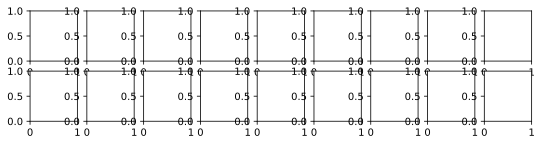

In [28]:
_, axes = d2l.plt.subplots(2, 9, figsize=(9, 2))
print(type(axes))

In [29]:
axes.flatten??

Docstring:
a.flatten(order='C')

Return a copy of the array collapsed into one dimension.

Parameters
----------
order : {'C', 'F', 'A', 'K'}, optional
    'C' means to flatten in row-major (C-style) order.
    'F' means to flatten in column-major (Fortran-
    style) order. 'A' means to flatten in column-major
    order if `a` is Fortran *contiguous* in memory,
    row-major order otherwise. 'K' means to flatten
    `a` in the order the elements occur in memory.
    The default is 'C'.

Returns
-------
y : ndarray
    A copy of the input array, flattened to one dimension.

See Also
--------
ravel : Return a flattened array.
flat : A 1-D flat iterator over the array.

Examples
--------
>>> a = np.array([[1,2], [3,4]])
>>> a.flatten()
array([1, 2, 3, 4])
>>> a.flatten('F')
array([1, 3, 2, 4])
Type:      builtin_function_or_method

接受一批图片， 要排成几行几列，标题（可选）缩放比例 = 1.5
'''绘制图表'''
figsize = 列和行乘上缩放比例 ， 放进figsize
_, axes = d2l.plt.subplots(num_rows, num_cols,figsize = figsize) 
这里的行列你先记一下是2行9列的意思， 不是 28*28 不要把这两个东西混淆了小提醒：num_rows、num_cols是"要排成几行几列"（比如2行9列），不是"图片本身是28行28列"——这是两个不同的概念。图片28×28是"这一张图内部的像素排列"；num_rows/num_cols是"一共18张图，要摆成几行几列的网格"。这两者别混了。
axes = axes.flatten() 

创建一个行 列的网格画布， 拉平成一维方便循环， 
for i , (ax,img) 



for i,(ax ,img) in enumerate (zip(axes, imgs)):
        if torch.is_tensor(img):
            #图片张量
            ax.imshow(img.numpy())
        else:
            #PIL图片
            ax.imshow(img) 
创建一个行*列， 的网格画布拉平成一维方便循环。 

逐张图配对到每一个格子， 画出来， tensor 先转numpy PIL 图片直接画
隐藏坐标轴贴标题 

**fig_kw。kwarge只是最常见的叫法， 作用， 把调用时没有被前面参数列表明确列出来的关键字参数打包进一个字典里

1.单独 * 不带名字  def subplots(nrows =1 , ncols=1,*,sharex = False, sharey = False ...):这里的* 单独出现的作用是一道分隔线， 规定， 这条线后面的所有参数必须使用， 参数名=值， 的方式传， 不能写值 


return fig ,axg fig是整张画布， 画布代表这个大容器， axe 是里面的小格子， 或者多个Axes对象， 一个元组两样东西，

你截图里的18个小方框 每个都有自己的x轴， y轴，刻度0.0 到1.0  每一个框就是一个axes 对象， ，也就是我们的小格子， axes这个变量， 就是装着18个方框对象的一个numpy 
这些方框还是空的， 因为你只是创建了网格 ， 还没往里面imshow 任何图片， show_images函数里先创建网格， 再逐个填图 这和show_image 函数里先创建网格再逐个填图，的流程是一致的
，关于，flatten的文档， 和builtin_function_or_method 跟torch完全没有关系和numpy 有关系， flatten 是numpy数组自带的方法， 只要你手里的变量是一个numpy数组，比如这里的axes就能直接.flatten()调用， 不需要你自己额外的import什么， 因为axes这个对象本身， 已经是plt.subplots() 返回给你的一个现成的numpy数组，flatten 这个能力是内置在这个数组对象身上， 你到的这个对象的那一刻能力自动就来了

builin_function_or_method 这个标签的意思是， 这是一个用底层代码 c语言实现的直接实现的内置方法， 不用存python, 这跟你自己写的类列的定义的饿普通的方法， 比如def f;atten(self） 性质不太一样 numpy为了运行速度更快，很多核心方法都是用更底层的语言，实现python这边只是提供一个调用接口


figsize值: (13.5, 3.0)
axes没有铺平前的值: [[<Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: >
  <Axes: >]
 [<Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: >
  <Axes: >]]
axes flatten后的值 [<Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: >
 <Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: >
 <Axes: > <Axes: >]
axes形状: (18,)
0
ax值 Axes(0.125,0.53;0.0731132x0.35)
1
ax值 Axes(0.212736,0.53;0.0731132x0.35)
2
ax值 Axes(0.300472,0.53;0.0731132x0.35)
3
ax值 Axes(0.388208,0.53;0.0731132x0.35)
4
ax值 Axes(0.475943,0.53;0.0731132x0.35)
5
ax值 Axes(0.563679,0.53;0.0731132x0.35)
6
ax值 Axes(0.651415,0.53;0.0731132x0.35)
7
ax值 Axes(0.739151,0.53;0.0731132x0.35)
8
ax值 Axes(0.826887,0.53;0.0731132x0.35)
9
ax值 Axes(0.125,0.11;0.0731132x0.35)
10
ax值 Axes(0.212736,0.11;0.0731132x0.35)
11
ax值 Axes(0.300472,0.11;0.0731132x0.35)
12
ax值 Axes(0.388208,0.11;0.0731132x0.35)
13
ax值 Axes(0.475943,0.11;0.0731132x0.35)
14
ax值 Axes(0.563679,0.1

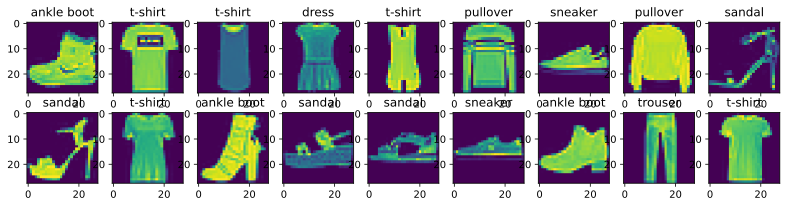

In [30]:
X,y = next(iter(data.DataLoader(mnist_train,batch_size=18)))
show_images(X.reshape(18,28,28),2,9,titles =get_fashion_mnist_labels(y));

In [31]:
#type(xaxis).__mro__

axes[0]  就是左上角的ankle boot括号里的数学时它在画布上的位置和大小， 格式是 Axes(左边距，下边距；宽*高）
Axes(0.826887,0.11;0.0731132x0.35)  单位不是英寸， 而是占整张画布的比例所以意思是， 这个小画格的左边在画布的12.5% 下边在53%高度处 ，宽度占画布的7.3%  高度占 35%  这些数字是可以手算出来的， matplotlib默认给画布四周流彩左边从0.125开始  右边到0.9 结束， 下边 0.11 上边 0.88 小图之间的间隙默认是小图宽（高）的0.2倍
宽度可以用 0.9 -0.125 = 0.775  9个小图加8个间隙， 
9w + 8 * 0.2w = 10.6w = 0.775 
w = 0.775 / 10.6 = 0.0731  
高度 可用高度 = 0.88 - 0.11 = 0.77  
2h + 0.2h = 2.2h = 0.77
h = 0.35 
下边距 第一行顶部贴到 0.88 往下一个高度， 0.88 - 0.35= 0.53 
先手算再打印 axes[1] axes[9] 对答案， axes[1] 只有左边距变量， axes[9]是第二行第一个， 只有下边距变了 

最后一行的读法是一个XAxis类型的对象， 这个类型定义在matplotlib 包的axis模块里，XAxis 就是横轴 包括那条轴线刻度， 刻度数字， 每个小画格Axes里面装的这个XAxis 和一个YAxis , get_xaxis() 就是把这个小画格的横轴拿出来， 然后.set_visible(False)把它藏起来 
用西门子的概念类比 类class 就像FB的类型， 对象就像她的背景数据块实例 Xaix是FB类型， xaxis 是一个具体的类实例， 的一个bool 变量， set_visible 就是写这个bool

用西门子的概念来类比class 就想FB 的类型， 对象就是它的背景数据块的实例， XAxis是FB 类型， xaxis就是一个具体的实例， _visible 就是实例里的一个bool变量， set_visible就是写这个bool 变量， 
 这里还有一个细节值得注意， 你查set_visible时， file显示的是artist.py不是axis.py 这是因为继承， XAxis继承自Axis Axi又继承自Artist. Artist是matplotlib里一切能画出来的东西的祖先， set_visible写在祖先里， 所有后台都能直接用， 可以运行


从里往外看， data.DataLoader(mnist_train,batch_size=18),把训练数据包装成一个每次突出18张图片的加载器 ， iter() 把它变成迭代器， next() 取出第一批结果x是图片， 形状是18，1，28，28 即18张图片， 1个通道灰度， 28*28 像素， y 是18个标签 是0-9 的整数
X 是图片， y 是18个标签。是0-9的整数
show_image(X,reshape(18,28,28),2,9,title = get_fashion_mnist_labels(y))
把y 是标签放到我的图片上去 


这里纠正一遍表述：
1.next 和iter:iter(...)把DataLoader变成了一个迭代器，可以理解成一个排好队的出料口， next(...)就是从出料口取下一个料，DataLoader每次出料是一批18*18的标签，所以next一次拿到的就是第一批 
2.scale = 1.5 不是放大1.5倍 而是每个小画框1.5英寸大 figsize 的单位是英寸：
宽 = 9列 * 1.5 = 13.5英寸
高 = 2行 * 1.5 = 3.0 英寸
所以 （ 13.5 ，3.0 ） 是整张画布的宽和高， 你可以把scale 改成3看看图变成列什么样

3.axes 不是两个列表， 而是一个形状为（2，9）的numpy 二维数组，就像plc 里的二维数组Array[0..1,0...8]你打印一下axes.shape就能确认 。fl attend（）把它变成列形状（18，）的一维数组，这样后面才能跟18张图对应
4.zip 不是压缩， 是拉链 把两排的东西左右对齐配对  
5.set_title 不是打印 是在小画框上写一行标题文字， print 是输出到下面的文本区 ， set_title 是画到图上两回事
6.ax.axes : ax 本身就是一个Axes ， ax.axes 指回它自己， 所以写ax.get_xaxis() 效果完全一样 树 




In [32]:
show_images??

Signature: show_images(imgs, num_rows, num_cols, titles=None, scale=1.5)
Source:   
def show_images(imgs, num_rows,num_cols,titles=None, scale = 1.5 ): #@save
    """绘制图像列表"""
    figsize = (num_cols * scale, num_rows * scale)
    print("figsize值:",figsize)

    _,axes = d2l.plt.subplots(num_rows, num_cols,figsize = figsize)
    print("axes没有铺平前的值:",axes)
    axes = axes.flatten()
    print("axes flatten后的值",axes)
    print("axes形状:",axes.shape)
    #print(axes)

    for i,(ax ,img) in enumerate (zip(axes, imgs)):
        print(i)
        #print(ax)
        #print(img)
        if torch.is_tensor(img):
            #图片张量
            ax.imshow(img.numpy())
        else:
            #PIL图片
            ax.imshow(img) 

        print("ax值",ax)
        ax.axes.get_xaxis().set_visible(True)
        ax.axes.get_yaxis().set_visible(True)
        if titles :
            ax.set_title(titles[i])
            pass
    return axes
File:      /var/folders/zk/2qt75bzd3pv_5vtwp70q5wbm0000gn/T/ipykernel_5

In [33]:
get_fashion_mnist_labels??

Signature: get_fashion_mnist_labels(labels)
Source:   
def get_fashion_mnist_labels(labels):
    """返回Fashion-MNIS数据集的文本标签"""
    """已经知道下标了， 把它翻译成文字"""
    text_labels = ['t-shirt','trouser','pullover','dress','coat',
                   'sandal','shirt','sneaker','bag','ankle boot']
    return [text_labels[int(i)] for i in labels]
File:      /var/folders/zk/2qt75bzd3pv_5vtwp70q5wbm0000gn/T/ipykernel_51904/1410677004.py
Type:      function

In [34]:
d2l.plt.rcParams['figure.subplot.left']


0.125

In [35]:
d2l.plt.rcParams['figure.subplot.left']

0.125

[<Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: >
 <Axes: >]


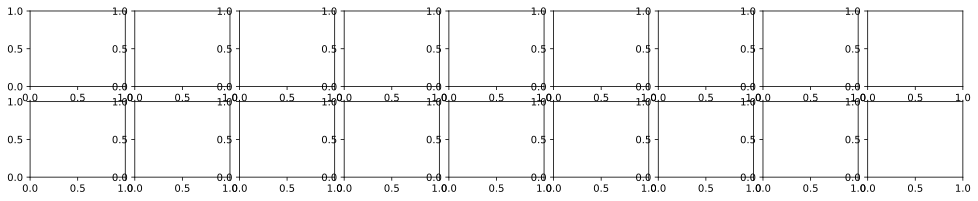

In [36]:
fig, axes = d2l.plt.subplots(2, 9, figsize=(13.5, 3.0))
fig.subplots_adjust(left=0.02, right=0.98, wspace=0.1)
print(axes[0])


读取小批量：
为了使我们在读取训练集和测试集时更容易， 我们使用内置的数据迭代器， 而不是从零开始创建， 在每次迭代中，数据加载每次都会读取一小批数据， 大小为batch_size， 通过内置数据迭代器， 我们可以随机打乱样本， 从而无偏见的读取小批量

In [37]:
batch_size= 256 

def get_dataloader_workers():
    """使用4个进程来读取数据"""
    return 4 

train_iter = data.DataLoader(mnist_train, batch_size, shuffle=True ,
                             num_workers = get_dataloader_workers())

batch_size是每一批拿256张图， 训练数据集是60000 60000/256=234.375
234个满批 加最后一个不满批的60000 - 234 *256 = 96 张


In [38]:
#print("train_iter:",list(train_iter))
len(train_iter)

235

我们来看一下读取训练数据所需要的时间
这里说的是4进程不是线程， 同时出现4个帮手， 
分工是这样的主要进程负责训练模型， 4个工作进程负责在后台准备数据， 也就是把图片读取出来，转成tensor 每256张打包成一批， 它们同时干活， 主进程要下一批时， 数据往往已经准备好了 ， 类比产线， 焊接工位是主进程， 4个上料工位提前把工件备好送过来， 焊接工位不用停下来等料 

In [39]:
import os
os.cpu_count()

10

In [40]:
timer= d2l.Timer()
for X,y in train_iter:
    continue 
f'{timer.stop():.2f}sec'

'1.73sec'

整合所有的组件 
现在我们定义来load_data_fashion_mnist函数， 用于获取和读取Fashion - MNIST数据集。 这个函数返回训练集，和验证集的数据集的数据迭代器， 此外这个函数还是接受来一个可选参数resize用来将图像大小调整为另一种形状

创建一个计时器，创建的瞬间 就开始计时
每次循环取出一批次， X是 256， y=256 个标签，  continue 什么都不做直接取下一批， 
f'{timer.stop():.2f}sec' 停表 显示用来多少秒
这段代码的目的是， 测试一下吧整个训练数据集完整的读一遍要多久， 循环里什么都没有做， 知识为了测度数据的速度 不参杂别的计算
continue 意思是跳过这一轮循环剩下的代码， 直接进入下一轮， 这里循环体里本来就没有别的代码， 等于它什么都不干， 之所以要写它， 是因为python的for 循环是不能空着的， 必须放点东西
timer.stop() 停表， 返回从开始到现在， 经过的秒数比如  

In [41]:
def load_data_fashion_mnist(batch_size,resize=None):
    """下载Fashion-MNIST数据集，然后将其加载到内存中"""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0,transforms.Resize(resize))
    trans = transforms.Compose(trans)
    mnist_train = torchvision.datasets.FashionMNIST(
        root="../data",train=True,transform=trans,download = True)
    mnist_test = torchvision.datasets.FashionMNIST(
        root="../data",train=False,transform= trans,download=True) 
    return (data.DataLoader(mnist_train,batch_size,shuffle=True,
                            num_workers = get_dataloader_workers()),
            data.DataLoader(mnist_test, batch_size,shuffle= False,
                            num_workers= get_dataloader_workers()))

In [84]:
for X,y in train_iter:
    print(X.shape,X.dtype,y.shape,y.dtype)
    break

torch.Size([256, 1, 28, 28]) torch.float32 torch.Size([256]) torch.int64


[256,1,28,28] 256张，1通道，28 * 28    float32 图片是小数 0-1 所以是浮点型，  torch.size([256])个标签  int 64  标签是0-9 所以是整数型

In [81]:
train_iter,test_iter = load_data_fashion_mnist(256,resize=0)
X,y=next(iter(train_iter))
print(X.shape)

torch.Size([256, 1, 28, 28])


In [86]:
train_iter,test_iter = load_data_fashion_mnist(32,resize=0)
X,y=next(iter(train_iter))
print(X.shape)

torch.Size([32, 1, 28, 28])


In [89]:
train_iter,test_iter = load_data_fashion_mnist(32,resize=64)
for X,y in train_iter:
    print(X.shape,X.dtype,y.shape,y.dtype)
    break

torch.Size([32, 1, 64, 64]) torch.float32 torch.Size([32]) torch.int64


[32,1,64,64] 32张 1通道，64*64 说明batch_size 和resize 都生效了
float32 图片是小数， （0-1） 所以是浮点型
[32] 32个标签
int64 标签是0-9 的整数 所以是整数型

In [82]:
a,b = load_data_fashion_mnist(256)
print(type(a),len(a),len(b))

<class 'torch.utils.data.dataloader.DataLoader'> 235 40


In [76]:
list.insert??

Signature: list.insert(self, index, object, /)
Docstring: Insert object before index.
Type:      method_descriptor

返回的不是数据集 是两个DataLoader 
这里有两个东西要分清楚 Dataset mnist_train 仓库里面放着全部的6万张图片，可以按编号取任意的一张，DataLoader返回值传送带的出料口 从仓库里按批次取货，每次送出256张
函数的返回值 是两个出料口放在一个元组里面， 

ok 60000张图片都放在里train_iter.dataset这个属性里是吗， 长度一共有 235个批次吗， 
2.num_workers 是进程不是线程 ， 
3.FashionMNIST 那一行在做什么
不是把存数据的地方放在mnist_train 上，而是创建一个数据集对象，同时告诉它四件事情，文件在哪 ，root 要拿一部分（trian =true)  每张图片怎么处理 tranform  没有就下载 
另外 这个时候的trans 已经不是ToTensor() 而是经过Compose 串好的整条流水线 ，如果给里resize 里面是先缩放还是转成tensor 两道工序

resize 的作用是 改变图片的大小，
原始图片是28*28像素，resize=64 就是把每张图片放大，64*64 你之前打印的[32,1,64,64] 最后两个64就是它的效果，不加 resize 这里是2828 
为什么要改大小 因为 有些模型规定了尺寸，比如d2l 后面学到累一些卷积神经网络要求输入224 8 224 28 * 28 的图 就得先放大 反过来也一样， 你以后做焊接检测相机拍的图可能是2000 多的像素宽太大了 要缩小 才能送进模型， 


if resize 的作用可选工序， 
函数定义里写的是resize= None 意思是这个参数可以不给，  所以有两种调用的方式
load_data_fashion_mnist（256，resize=64) 


In [74]:
print(bool(None))
print(bool(64))
print(bool(0))

False
True
False


In [71]:
print(len(train_iter.dataset),len(train_iter))

60000 235


In [69]:
train_iter,test_iter = load_data_fashion_mnist(256)
print(len(train_iter),len(test_iter))

X,y =next(iter(train_iter))
print(X.shape,y.shape)

235 40
torch.Size([256, 1, 28, 28]) torch.Size([256])


看缩进 trans = transforms .compose(trans) 和if 是对齐的 所以不管if成立不成立， 这一行都会执行，因为无论清单里有一道还是两道工序
最后都串成流水线 
不给 resize , trans = [ToTensor] if  跳过 ，  trans = transforms.compose(trans) 







测试集10000张 每批256 不满的后面也算一批， 第二行不带resize 形状应该是多少


这里我们来说函数的作用，把前面这一节学习的所有步骤，下载数据，预处理图片，分批读取，打包成一个函数，以后softmax那一张只要一行就能拿到数据
train_iter,teset_iter = load_data_fashion_mnist(256) 

trans = [transforms.ToTensor()] trans是一个列表，里面放的是处理图片的工序，ToTensor() 它做两件事，1.把图片转成tensor 形状[1,28,28]  2.把像素值从0-255除以255 变成0-1 

你之前看到的0.0039 就是1/255 就是这道工序的结果。
if resize: 
train.insert(0,transforms.Resize(resize))
如果调用时给里resize 比如64 就在清单的第0 个位置 最前面 插入一道缩放的工序， 没给的话，resize是None if None 相当于if False ,插入之后的清单变成[Resize（64），ToTensor ()] 先缩放 再转tensor 
trans = transforms.Compose(trans) 
Compose 把清单里的工序串成一条流水线，之后每张图片进来就按顺序过每个工位
原始图片 - Resize(64) - ToTensor() - 处理好的tensor 
mnist_train = torchvision.datasets.FashionMNIST(
    root =" ../data",train=True,transform = trans,download=True)
mnist_test = torchvision.datasets.FashionMNIST(
    root ="../data",train=False,transform=trans,download=True)

    root ="..data"数据存的文件
    train_True 拿训练的6万张图片，train=False 拿测试集1万张
    transform = trans 每读一张图 就让它一遍上面的那条流水线 
    download = True 文件夹里没有自动下载，有了就直接用

注意 流水线不是开始就是7万张图全部处理一遍， 而是每读一张，就处理一张

第三段 返回两个DataLoader 
return （data.DataLoader(mnist_train,batch_size,shuffle=True,
            num_workers=get_dataloader_workers()),
        data.DataLoader(mnist_test,batch_size,shuffle=False,
            num_workers=get_dataloader_workers())

这就是你刚学的DataLoader一次返回两个 一个读训练数据集， 一个读测试数据集 唯一的区别是要不要shuffle 
第一行末尾的#@save 是d2l的一个标记，意思是这个函数已经存在里d2l包里了，后面的章节直接写d2l.load_data_fashion_mnist(..)不用自己定义一遍
train_iter,test_iter = load_data_fashion_mnist(256)
print(



下面我们通过指定resize参数来测试load_data_fashion_mnist函数的图像大小调整功能

In [94]:
train_iter, test_iter =load_data_fashion_mnist(32,resize=64)
for X,y in train_iter:
    print('X是:',X,'Y是',y)
    print(X.shape,X.dtype,y.shape,y.dtype)
    break
    

X是: tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        ...,


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ...

In [95]:
X[0,0,28:36,28:36]

tensor([[0.8980, 0.8980, 0.9020, 0.9020, 0.8980, 0.8980, 0.9020, 0.9020],
        [0.8980, 0.8980, 0.9020, 0.9020, 0.8980, 0.8980, 0.9020, 0.9020],
        [0.9020, 0.9020, 0.9020, 0.9020, 0.9020, 0.9020, 0.9020, 0.9020],
        [0.9020, 0.9020, 0.9020, 0.9020, 0.9020, 0.9020, 0.9020, 0.9020],
        [0.9059, 0.9059, 0.9020, 0.9020, 0.9020, 0.9020, 0.9020, 0.9020],
        [0.9059, 0.9059, 0.9020, 0.9020, 0.9020, 0.9020, 0.9020, 0.9020],
        [0.9059, 0.9059, 0.9020, 0.9020, 0.9020, 0.9020, 0.9020, 0.9020],
        [0.9059, 0.9059, 0.9020, 0.9020, 0.9020, 0.9020, 0.9020, 0.9020]])

figsize值: (12.0, 1.5)
axes没有铺平前的值: [<Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: >]
axes flatten后的值 [<Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: >]
axes形状: (8,)
0
ax值 Axes(0.125,0.11;0.0824468x0.77)
1
ax值 Axes(0.223936,0.11;0.0824468x0.77)
2
ax值 Axes(0.322872,0.11;0.0824468x0.77)
3
ax值 Axes(0.421809,0.11;0.0824468x0.77)
4
ax值 Axes(0.520745,0.11;0.0824468x0.77)
5
ax值 Axes(0.619681,0.11;0.0824468x0.77)
6
ax值 Axes(0.718617,0.11;0.0824468x0.77)
7
ax值 Axes(0.817553,0.11;0.0824468x0.77)


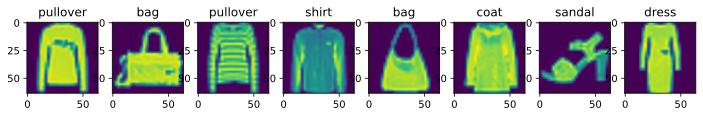

In [98]:
show_images(X[:8].reshape(8,64,64),1,8,
           titles=get_fashion_mnist_labels(y[:8]));

In [43]:
batches = list(train_iter)
print(len(batches))
print(batches[0][0].shape)

1875
torch.Size([32, 1, 64, 64])


In [44]:
batches = list(train_iter)
print(len(batches))
print(batches[0][0].shape)
print(batches[0][1].shape)
print(batches[-1][0].shape)

1875
torch.Size([32, 1, 64, 64])
torch.Size([32])
torch.Size([32, 1, 64, 64])


In [56]:
for workers in [0,4,8]:
    it = data.DataLoader(mnist_train,batch_size=256,shuffle=True,num_workers=workers)
    timer = d2l.Timer()
    for X,y in it : 
        continue 
    print(workers,f'{timer.stop():.2f}sec')

0 0.70sec
4 1.63sec
8 2.25sec


In [57]:
for worker in [0,4,8]:
    it = data.DataLoader(mnist_train, batch_size=256,shuffle=True,num_workers=workers)
    timer = d2l.Timer()
    next(iter(it))
    print(worker,f'{timer.stop():.2f}sec')

0 2.09sec
4 2.24sec
8 2.14sec


In [60]:
for worker in [0,4,8]:
    it = data.DataLoader(mnist_train,batch_size=256,shuffle=True,num_workers = worker)
    timer = d2l.Timer()
    next(iter(it))
    print(worker,it.num_workers,f'{timer.stop():.2f}sec')

0 0 0.02sec
4 4 1.70sec
8 8 2.18sec


In [66]:
from collections import Counter
def collate (batch):
    info = data.get_worker_info()
    X,y =data.default_collate(batch)
    return X,y,info.id

it = data.DataLoader(mnist_train,batch_size=256,shuffle =True,
                     num_workers= 4,collate_fn = collate,
                     multiprocessing_context='fork')

ids = [w for X,y,w in it ]
print(ids[:12])
print(Counter(ids))

[0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3]
Counter({0: 59, 1: 59, 2: 59, 3: 58})


第一步先认识一个新的概念 collate 打包
帮手拿到一张清单取256张图取回来的256是散件， 是一对（图片，标签）： [(图1, 9), (图2, 0), (图3, 0), …… 一共 256 对]
这样没有办法直接使用， 还需要一个大包的步骤， 把256张图叠成一个大的tensorX 形状[256,1,28,28]把256个标签排成一个y [形状[256]] 这个动作就叫打包 collate 
平时你用的DataLoader 时它会自动调用一个默认打包函数， default_collate 你看不到而已
第二步：
def collate(batch):
  info = data.get_worker_info()  #帮手问自己 我是几号
  X,y = data.default_collate(batch)。#照常打包， 和默认的一样
  return X,y info.id   #交回去的时候多带一张标签， 我的编号， 
  batch 就是那256个散件， get_work_info 在帮手的进程里调用能拿到这个帮手的信息，info.id 就是他的编号
  default_collate(batch) 默认的打包动作 我们不改它 照用
  return X,y info.id 原本值交回的X和y两样东西现在多交一个编号 
  it = 
  

In [68]:
print(len(ids))
print(ids[-1])

235
2


In [79]:
a = ['B','C']
a.insert(0,'A')
print(a)
a.insert(2,'x')
print(a)

['A', 'B', 'C']
['A', 'B', 'x', 'C']
